#1. Data Exploration and Preprocessing

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
import re

# Download NLTK resources
nltk.download("stopwords")
nltk.download("punkt")
# Download the punkt_tab data package
nltk.download('punkt_tab') # This line is added to download the missing data package.

# Load the dataset
data = pd.read_csv('/content/blogs.csv')

# Exploratory Data Analysis
print(data.info())
print(data["Data"].head())
print(data["Labels"].value_counts())

# Preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    # Tokenize and remove stopwords
    stop_words = set(stopwords.words("english"))
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return " ".join(filtered_tokens)

# Apply preprocessing to the Data column
data["Cleaned_Data"] = data["Data"].apply(preprocess_text)

# Feature extraction using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data["Cleaned_Data"]).toarray()
y = data["Labels"]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB
None
0    Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...
1    Newsgroups: alt.atheism\nPath: cantaloupe.srv....
2    Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...
3    Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...
4    Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...
Name: Data, dtype: object
Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electron

#2. Naive Bayes Model for Text Classification

In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.84
Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.50      0.83      0.62        18
           comp.graphics       0.75      0.83      0.79        18
 comp.os.ms-windows.misc       0.91      0.91      0.91        22
comp.sys.ibm.pc.hardware       0.81      0.84      0.82        25
   comp.sys.mac.hardware       0.86      0.90      0.88        21
          comp.windows.x       0.95      0.84      0.89        25
            misc.forsale       1.00      0.78      0.88        18
               rec.autos       0.90      1.00      0.95        18
         rec.motorcycles       1.00      0.94      0.97        16
      rec.sport.baseball       0.80      0.89      0.84        18
        rec.sport.hockey       0.88      1.00      0.94        15
               sci.crypt       0.90      1.00      0.95        19
         sci.electronics       0.67      0.75      0.71        16
                 sci.med       0.88  

#3. Sentiment Analysis

In [9]:
from textblob import TextBlob

# Function to get sentiment
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return "Positive"
    elif analysis.sentiment.polarity < 0:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis to the Data column
data["Sentiment"] = data["Data"].apply(get_sentiment)

# Analyze the distribution of sentiments
print(data["Sentiment"].value_counts())

# Sentiment distribution across categories
sentiment_category = data.groupby(["Labels", "Sentiment"]).size().unstack()
print(sentiment_category)


Sentiment
Positive    1543
Negative     457
Name: count, dtype: int64
Sentiment                 Negative  Positive
Labels                                      
alt.atheism                     23        77
comp.graphics                   24        76
comp.os.ms-windows.misc         22        78
comp.sys.ibm.pc.hardware        20        80
comp.sys.mac.hardware           24        76
comp.windows.x                  27        73
misc.forsale                    16        84
rec.autos                       17        83
rec.motorcycles                 26        74
rec.sport.baseball              29        71
rec.sport.hockey                34        66
sci.crypt                       19        81
sci.electronics                 19        81
sci.med                         29        71
sci.space                       27        73
soc.religion.christian          13        87
talk.politics.guns              30        70
talk.politics.mideast           22        78
talk.politics.misc            

#4. Evaluation and Discussion

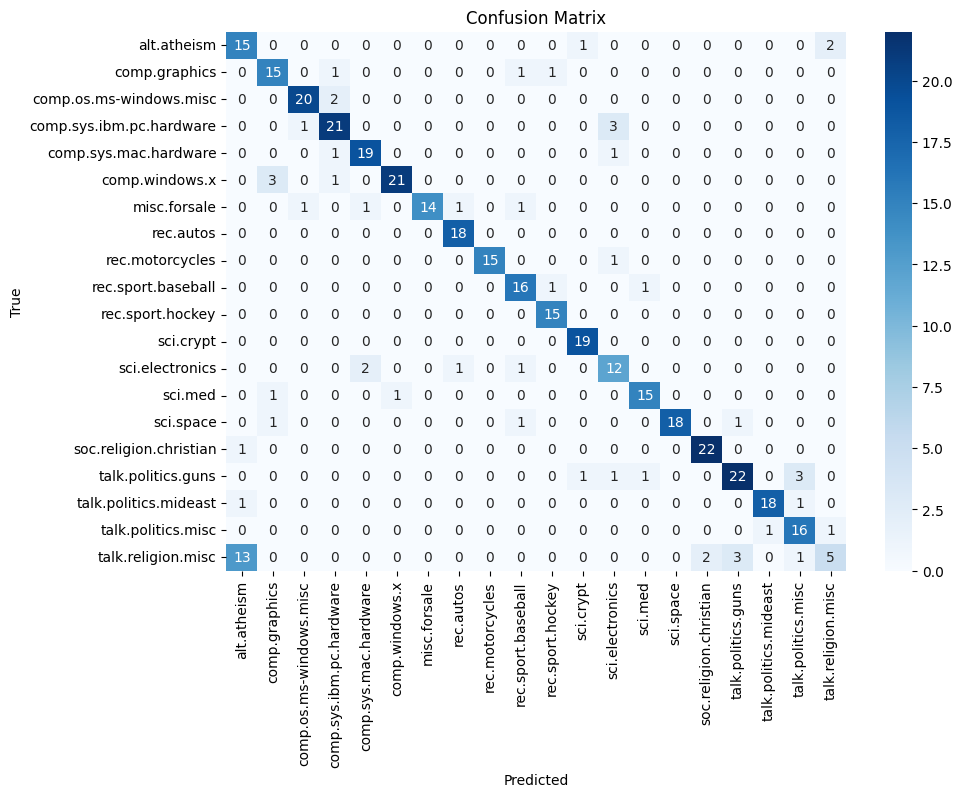

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


#Discussion:
##Naive Bayes Classifier:

* Accuracy: Based on the model evaluation, discuss how well it performs.

* Challenges: Address any challenges, such as misclassifications or imbalanced data.

##Sentiment Analysis:

* Distribution of sentiments across categories provides insights into the tone and nature of the blog posts.

* For example, certain categories may have more positive posts, while others lean negative or neutral.



#Additional Insights
* Model Performance: Compare the classification report and confusion matrix to identify which categories are more challenging for the Naive Bayes model.

* Sentiment Insights: Analyze sentiment trends within each category. For example, does a specific category tend to have more negative sentiments?